In [2]:
from google.colab import files
uploaded = files.upload()

import zipfile

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

Saving archive (7).zip to archive (7).zip


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

In [4]:
import os

base_path = "/content/dataset"

for root, dirs, files in os.walk(base_path):
    print("📂", root)
    for d in dirs:
        print("   └──", d)

📂 /content/dataset
   └── rice_leaf_diseases
📂 /content/dataset/rice_leaf_diseases
   └── Leaf smut
   └── Brown spot
   └── Bacterial leaf blight
📂 /content/dataset/rice_leaf_diseases/Leaf smut
📂 /content/dataset/rice_leaf_diseases/Brown spot
📂 /content/dataset/rice_leaf_diseases/Bacterial leaf blight


Cleaning dataset...

  CLEANING REPORT
  Total scanned : 120
  Corrupt       : 0
  Too small     : 0
  Blurry        : 80
  Duplicates    : 0
  Accepted      : 40

  Per-class:
    Bacterial leaf blight          kept=4  dropped=36
    Brown spot                     kept=20  dropped=20
    Leaf smut                      kept=16  dropped=24

Classes : [np.str_('Bacterial leaf blight'), np.str_('Brown spot'), np.str_('Leaf smut')]
Total   : 40 images
  Bacterial leaf blight          4 images
  Brown spot                     20 images
  Leaf smut                      16 images


Model: "RiceDisease_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_bn1 (BatchNormalization) │ (None, 16, 16, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_relu1 (Activation)       │ (None, 16, 16, 256)    │             

 Total params: 1,275,363 (4.87 MB)

 Trainable params: 1,272,675 (4.85 MB)

 Non-trainable params: 2,688 (10.50 KB)


Total trainable parameters: 1,275,363

  CUSTOM CNN — 5-FOLD CROSS VALIDATION

────────────────────────────────────────
  FOLD 1/5
────────────────────────────────────────
  Augmenting 33 train images × 12...
  Train (aug): 429  |  Val: 7
  Ep  1/40 | lr=1.00e-03 | loss=1.190 acc=0.505 | val_loss=0.787 val_acc=0.571
  Ep  2/40 | lr=9.98e-04 | loss=1.278 acc=0.531 | val_loss=1.160 val_acc=0.429
  Ep  3/40 | lr=9.94e-04 | loss=1.092 acc=0.555 | val_loss=0.790 val_acc=0.714
  Ep  4/40 | lr=9.86e-04 | loss=1.109 acc=0.530 | val_loss=1.485 val_acc=0.429
  Ep  5/40 | lr=9.76e-04 | loss=1.029 acc=0.660 | val_loss=1.025 val_acc=0.571
  Ep  6/40 | lr=9.62e-04 | loss=0.939 acc=0.628 | val_loss=1.408 val_acc=0.429
  Ep  7/40 | lr=9.46e-04 | loss=0.972 acc=0.653 | val_loss=0.599 val_acc=0.714
  Ep  8/40 | lr=9.26e-04 | loss=1.065 acc=0.594 | val_loss=1.280 val_acc=0.571
  Ep  9/40 | lr=9.05e-04 | loss=0.928 acc=0.651 | val_loss=0.610 val_acc=0.857
  Ep 10/40 | lr=8.80e-04 | loss=0.820 acc=0.652 |

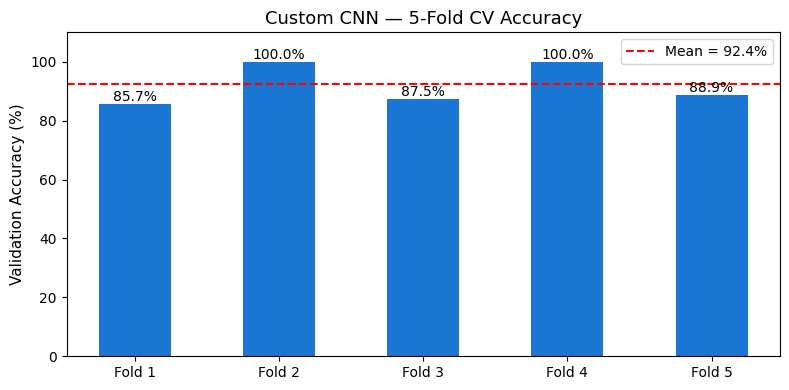

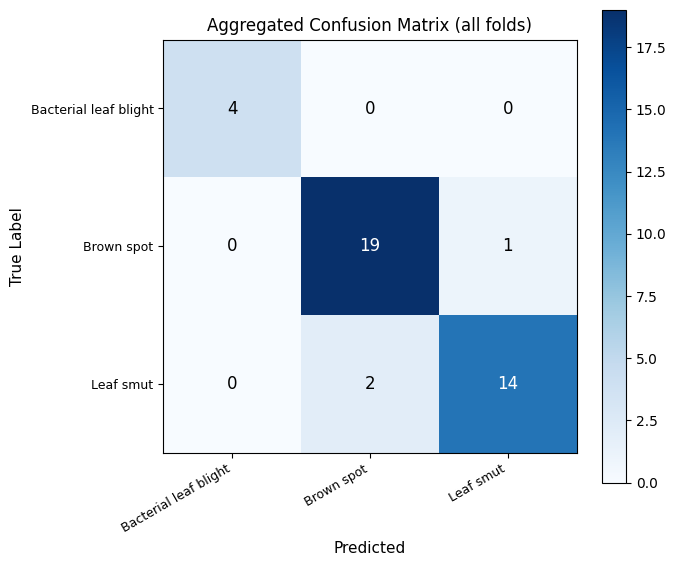

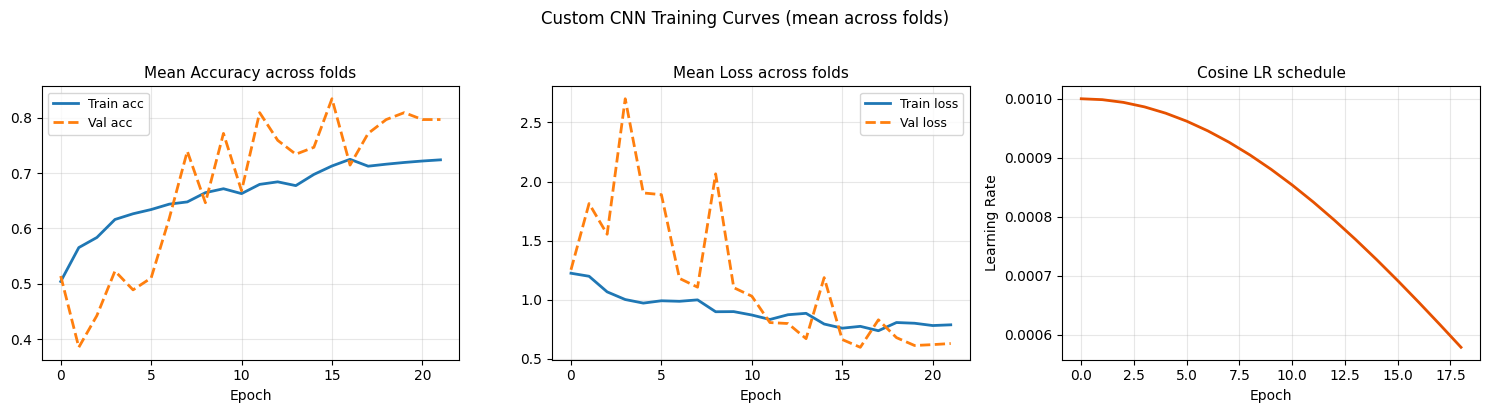

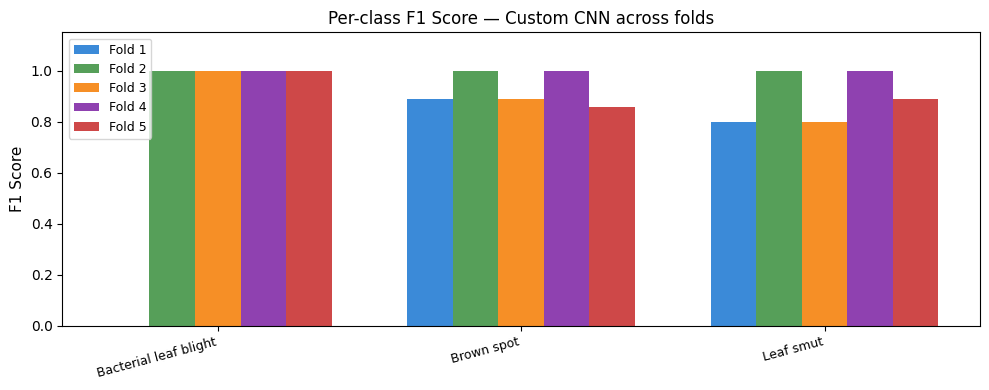

In [4]:
import os
import cv2
import numpy as np
import hashlib
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# CONFIG
# ============================================================
IMG_SIZE     = 128       # Smaller — custom CNN trains faster
BATCH_SIZE   = 8
EPOCHS       = 40        # More epochs needed — training from scratch
K_FOLDS      = 5
AUG_FACTOR   = 12        # Heavy augmentation — no pretrained features
BLUR_THRESH  = 50.0
MIN_DIM      = 32
dataset_path = "/content/dataset/rice_leaf_diseases"

# ============================================================
# STEP 0 — DATASET CLEANING (unchanged from before)
# ============================================================
def is_corrupt(path):
    return cv2.imread(path) is None

def laplacian_variance(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def clean_dataset(dataset_path):
    valid_paths, valid_labels = [], []
    seen_hashes = set()
    report = {'total':0,'corrupt':0,'small':0,
              'blurry':0,'duplicate':0,'accepted':0,'per_class':{}}

    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue
        report['per_class'][class_name] = {'accepted':0,'rejected':0}

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            report['total'] += 1

            if is_corrupt(img_path):
                report['corrupt'] += 1
                report['per_class'][class_name]['rejected'] += 1
                continue

            img  = cv2.imread(img_path)
            h, w = img.shape[:2]

            if h < MIN_DIM or w < MIN_DIM:
                report['small'] += 1
                report['per_class'][class_name]['rejected'] += 1
                continue

            fhash = file_hash(img_path)
            if fhash in seen_hashes:
                report['duplicate'] += 1
                report['per_class'][class_name]['rejected'] += 1
                continue
            seen_hashes.add(fhash)

            if laplacian_variance(img) < BLUR_THRESH:
                report['blurry'] += 1
                report['per_class'][class_name]['rejected'] += 1
                continue

            valid_paths.append(img_path)
            valid_labels.append(class_name)
            report['accepted'] += 1
            report['per_class'][class_name]['accepted'] += 1

    return valid_paths, valid_labels, report

print("Cleaning dataset...")
valid_paths, valid_labels, report = clean_dataset(dataset_path)

print(f"\n{'='*50}")
print(f"  CLEANING REPORT")
print(f"{'='*50}")
print(f"  Total scanned : {report['total']}")
print(f"  Corrupt       : {report['corrupt']}")
print(f"  Too small     : {report['small']}")
print(f"  Blurry        : {report['blurry']}")
print(f"  Duplicates    : {report['duplicate']}")
print(f"  Accepted      : {report['accepted']}")
print(f"\n  Per-class:")
for cls, c in report['per_class'].items():
    print(f"    {cls:<30} kept={c['accepted']}  dropped={c['rejected']}")

# ============================================================
# STEP 1 — LOAD IMAGES
# ============================================================
data, labels = [], []
for path, label in zip(valid_paths, valid_labels):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    data.append(img)
    labels.append(label)

data   = np.array(data,   dtype=np.float32)
labels = np.array(labels)

unique_classes = sorted(list(set(labels)))
num_classes    = len(unique_classes)
label_map      = {cls: i for i, cls in enumerate(unique_classes)}
idx_to_class   = {i: cls for cls, i in label_map.items()}
labels_int     = np.array([label_map[l] for l in labels])

def to_one_hot(y, n):
    ohe = np.zeros((len(y), n), dtype=np.float32)
    for i, v in enumerate(y):
        ohe[i][v] = 1.0
    return ohe

print(f"\nClasses : {unique_classes}")
print(f"Total   : {len(data)} images")
for c, cls in idx_to_class.items():
    print(f"  {cls:<30} {int(np.sum(labels_int==c))} images")

# ============================================================
# STEP 2 — AUGMENTATION (all manual numpy/cv2)
# ============================================================
def h_flip(img):  return img[:, ::-1, :]
def v_flip(img):  return img[::-1, :, :]

def rotate(img, max_angle=40):
    angle    = np.random.uniform(-max_angle, max_angle)
    h, w     = img.shape[:2]
    rad      = np.deg2rad(angle)
    ca, sa   = np.cos(rad), np.sin(rad)
    cx, cy   = w/2, h/2
    M = np.array([[ca, -sa, cx*(1-ca)+cy*sa],
                  [sa,  ca, cy*(1-ca)-cx*sa]], dtype=np.float64)
    return cv2.warpAffine(img, M, (w,h),
                          flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_REFLECT)

def zoom(img, lo=0.80, hi=1.20):
    f        = np.random.uniform(lo, hi)
    h, w     = img.shape[:2]
    nh, nw   = int(h*f), int(w*f)
    r        = cv2.resize(img, (nw, nh))
    if f > 1:
        sh, sw = (nh-h)//2, (nw-w)//2
        return r[sh:sh+h, sw:sw+w]
    canvas   = np.zeros_like(img)
    ph, pw   = (h-nh)//2, (w-nw)//2
    canvas[ph:ph+nh, pw:pw+nw] = r
    return canvas

def translate(img, ms=0.15):
    h, w = img.shape[:2]
    tx   = int(np.random.uniform(-ms, ms)*w)
    ty   = int(np.random.uniform(-ms, ms)*h)
    M    = np.float32([[1,0,tx],[0,1,ty]])
    return cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT)

def brightness(img, d=0.35):
    return np.clip(img + np.random.uniform(-d,d), 0, 1)

def contrast(img, lo=0.6, hi=1.4):
    f  = np.random.uniform(lo, hi)
    mu = img.mean(axis=(0,1), keepdims=True)
    return np.clip((img-mu)*f+mu, 0, 1)

def gauss_noise(img, std=0.03):
    return np.clip(img + np.random.normal(0,std,img.shape).astype(np.float32), 0, 1)

def ch_shuffle(img):
    return img[:,:,np.random.permutation(3)]

def cutout(img, size=30):
    img  = img.copy()
    h, w = img.shape[:2]
    cy   = np.random.randint(0, h)
    cx   = np.random.randint(0, w)
    y1,y2 = max(0,cy-size//2), min(h,cy+size//2)
    x1,x2 = max(0,cx-size//2), min(w,cx+size//2)
    img[y1:y2, x1:x2] = 0.5
    return img

def augment(img):
    ops = [(0.6, h_flip),
           (0.3, v_flip),
           (0.7, lambda x: rotate(x, 40)),
           (0.6, zoom),
           (0.6, translate),
           (0.7, brightness),
           (0.7, contrast),
           (0.5, gauss_noise),
           (0.3, ch_shuffle),
           (0.4, lambda x: cutout(x, 30))]
    for prob, fn in ops:
        if np.random.rand() < prob:
            img = fn(img)
    return img.astype(np.float32)

def augment_fold(X, y_int, factor):
    ax, ay = [], []
    for i in range(len(X)):
        for _ in range(factor):
            ax.append(augment(X[i]))
            ay.append(y_int[i])
    return np.array(ax, dtype=np.float32), np.array(ay)

# ============================================================
# STEP 3 — MANUAL CLASS WEIGHTS
# ============================================================
def class_weights_manual(y_int, n):
    n_total = len(y_int)
    return {c: n_total/(n * np.sum(y_int==c)) for c in range(n)}

# ============================================================
# STEP 4 — CUSTOM CNN (built entirely from scratch)
#
#  Architecture follows a VGG-style pattern:
#  double Conv blocks with doubling filter counts,
#  BatchNorm after every conv for stable training,
#  MaxPool to halve spatial dims each block,
#  GlobalAveragePooling instead of raw Flatten to
#  reduce parameters and overfitting on small data.
# ============================================================
def conv_block(x, filters, block_id):
    """
    Two Conv2D layers → BatchNorm → ReLU → MaxPool.
    Two convolutions per block (instead of one) lets
    the network learn more complex features at each scale.
    """
    # First conv
    x = tf.keras.layers.Conv2D(
        filters, (3,3), padding='same',
        use_bias=False,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        name=f'block{block_id}_conv1'
    )(x)
    x = tf.keras.layers.BatchNormalization(name=f'block{block_id}_bn1')(x)
    x = tf.keras.layers.Activation('relu', name=f'block{block_id}_relu1')(x)

    # Second conv (same filter count — deepens without shrinking)
    x = tf.keras.layers.Conv2D(
        filters, (3,3), padding='same',
        use_bias=False,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        name=f'block{block_id}_conv2'
    )(x)
    x = tf.keras.layers.BatchNormalization(name=f'block{block_id}_bn2')(x)
    x = tf.keras.layers.Activation('relu', name=f'block{block_id}_relu2')(x)

    # Spatial downsampling
    x = tf.keras.layers.MaxPooling2D((2,2), name=f'block{block_id}_pool')(x)
    return x

def build_custom_cnn(num_classes, img_size=IMG_SIZE):
    """
    Pure custom CNN — no pretrained weights, no transfer learning.
    Designed for small datasets:
      - L2 regularization on every conv to prevent overfitting
      - BatchNorm for stable gradient flow from scratch
      - GlobalAveragePooling to reduce parameter count vs Flatten
      - Two Dropout layers in head for regularization
    """
    inputs = tf.keras.Input(shape=(img_size, img_size, 3), name='input')

    # ---- Feature extraction backbone ----
    # Block 1: 128×128×3  → 64×64×32
    x = conv_block(inputs, filters=32,  block_id=1)
    # Block 2: 64×64×32   → 32×32×64
    x = conv_block(x,      filters=64,  block_id=2)
    # Block 3: 32×32×64   → 16×16×128
    x = conv_block(x,      filters=128, block_id=3)
    # Block 4: 16×16×128  → 8×8×256
    x = conv_block(x,      filters=256, block_id=4)

    # ---- Global feature aggregation ----
    # GlobalAveragePooling: 8×8×256 → 256
    # Preferred over Flatten (8×8×256 = 16384 params) for small datasets
    x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)

    # ---- Classifier head ----
    x = tf.keras.layers.Dense(
        256, use_bias=False,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        name='dense1'
    )(x)
    x = tf.keras.layers.BatchNormalization(name='head_bn1')(x)
    x = tf.keras.layers.Activation('relu', name='head_relu1')(x)
    x = tf.keras.layers.Dropout(0.5, name='drop1')(x)

    x = tf.keras.layers.Dense(
        128, use_bias=False,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        name='dense2'
    )(x)
    x = tf.keras.layers.BatchNormalization(name='head_bn2')(x)
    x = tf.keras.layers.Activation('relu', name='head_relu2')(x)
    x = tf.keras.layers.Dropout(0.3, name='drop2')(x)

    outputs = tf.keras.layers.Dense(
        num_classes, activation='softmax', name='output'
    )(x)

    model = tf.keras.Model(inputs, outputs, name='RiceDisease_CNN')
    return model

# Print architecture once
demo = build_custom_cnn(num_classes)
demo.summary()
total_params = demo.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")
del demo

# ============================================================
# STEP 5 — MANUAL METRICS
# ============================================================
def confusion_matrix_manual(y_true, y_pred, n):
    cm = np.zeros((n,n), dtype=np.int32)
    for t,p in zip(y_true, y_pred):
        cm[t][p] += 1
    return cm

def metrics_manual(cm, class_names):
    n = len(class_names)
    results, total = {}, cm.sum()
    for c in range(n):
        tp = cm[c,c]
        fp = cm[:,c].sum() - tp
        fn = cm[c,:].sum() - tp
        pr = tp/(tp+fp) if (tp+fp)>0 else 0.0
        rc = tp/(tp+fn) if (tp+fn)>0 else 0.0
        f1 = 2*pr*rc/(pr+rc) if (pr+rc)>0 else 0.0
        results[class_names[c]] = {'precision':pr,'recall':rc,
                                   'f1':f1,'support':int(cm[c].sum())}
    acc = np.trace(cm)/total
    mp  = np.mean([results[c]['precision'] for c in class_names])
    mr  = np.mean([results[c]['recall']    for c in class_names])
    mf  = np.mean([results[c]['f1']        for c in class_names])
    wp  = sum(results[c]['precision']*results[c]['support'] for c in class_names)/total
    wr  = sum(results[c]['recall']   *results[c]['support'] for c in class_names)/total
    wf  = sum(results[c]['f1']       *results[c]['support'] for c in class_names)/total
    return results, acc, (mp,mr,mf), (wp,wr,wf)

# ============================================================
# STEP 6 — MANUAL TRAINING LOOP WITH COSINE LR DECAY
# ============================================================
def cosine_lr(epoch, total_epochs, lr_max=1e-3, lr_min=1e-6):
    """
    Cosine annealing schedule — no external scheduler needed.
    LR starts at lr_max and smoothly decays to lr_min.
    Much better than fixed LR for training from scratch.
    """
    return lr_min + 0.5*(lr_max - lr_min)*(1 + np.cos(np.pi * epoch / total_epochs))

def run_epoch(model, X, y_ohe, y_int, batch_size,
              optimizer, is_training, cw_dict):
    n   = len(X)
    idx = np.random.permutation(n) if is_training else np.arange(n)
    losses, accs = [], []

    for start in range(0, n, batch_size):
        b   = idx[start:start+batch_size]
        Xb  = X[b]
        yb  = y_ohe[b]
        ybi = y_int[b]

        if is_training:
            with tf.GradientTape() as tape:
                preds = model(Xb, training=True)
                logp  = tf.math.log(tf.clip_by_value(preds, 1e-8, 1.0))
                xent  = -tf.reduce_sum(yb * logp, axis=1)
                sw    = tf.constant([cw_dict[int(c)] for c in ybi],
                                    dtype=tf.float32)
                loss  = tf.reduce_mean(xent * sw)
            grads = tape.gradient(loss, model.trainable_variables)
            # Gradient clipping — prevents exploding gradients when
            # training from scratch
            grads, _ = tf.clip_by_global_norm(grads, clip_norm=1.0)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
        else:
            preds = model(Xb, training=False)
            logp  = tf.math.log(tf.clip_by_value(preds, 1e-8, 1.0))
            xent  = -tf.reduce_sum(yb * logp, axis=1)
            loss  = tf.reduce_mean(xent)

        losses.append(float(loss))
        accs.append(np.mean(np.argmax(preds.numpy(), axis=1) == ybi))

    return np.mean(losses), np.mean(accs)

# ============================================================
# STEP 7 — MANUAL STRATIFIED K-FOLD
# ============================================================
def make_kfold_indices(labels_int, n_classes, k):
    class_idx = {}
    for c in range(n_classes):
        idx = np.where(labels_int==c)[0]
        np.random.shuffle(idx)
        class_idx[c] = idx

    folds = []
    for fold in range(k):
        val_idx, train_idx = [], []
        for c in range(n_classes):
            idx   = class_idx[c]
            n     = len(idx)
            start = (fold*n)//k
            end   = ((fold+1)*n)//k
            val_idx.extend(idx[start:end])
            train_idx.extend(np.concatenate([idx[:start], idx[end:]]))
        folds.append((np.array(train_idx), np.array(val_idx)))
    return folds

np.random.seed(42)
folds = make_kfold_indices(labels_int, num_classes, K_FOLDS)

# ============================================================
# STEP 8 — K-FOLD TRAINING
# ============================================================
fold_accuracies = []
fold_reports    = []
fold_histories  = []
all_cms         = np.zeros((num_classes, num_classes), dtype=np.int32)

print(f"\n{'='*55}")
print(f"  CUSTOM CNN — {K_FOLDS}-FOLD CROSS VALIDATION")
print(f"{'='*55}")

for fold_idx, (train_idx, val_idx) in enumerate(folds):
    print(f"\n{'─'*40}")
    print(f"  FOLD {fold_idx+1}/{K_FOLDS}")
    print(f"{'─'*40}")

    X_tr_raw = data[train_idx]
    y_tr_raw = labels_int[train_idx]
    X_val    = data[val_idx]
    y_val_i  = labels_int[val_idx]
    y_val    = to_one_hot(y_val_i, num_classes)

    # Augment training fold
    print(f"  Augmenting {len(X_tr_raw)} train images × {AUG_FACTOR}...")
    aug_X, aug_y = augment_fold(X_tr_raw, y_tr_raw, AUG_FACTOR)
    X_tr   = np.concatenate([X_tr_raw, aug_X])
    y_tr_i = np.concatenate([y_tr_raw, aug_y])
    y_tr   = to_one_hot(y_tr_i, num_classes)

    perm   = np.random.permutation(len(X_tr))
    X_tr, y_tr_i, y_tr = X_tr[perm], y_tr_i[perm], y_tr[perm]
    print(f"  Train (aug): {len(X_tr)}  |  Val: {len(X_val)}")

    cw    = class_weights_manual(y_tr_i, num_classes)
    model = build_custom_cnn(num_classes)

    # Cosine LR: starts at 1e-3, decays smoothly over EPOCHS
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    best_val_acc  = -np.inf
    best_weights  = None
    patience_cnt  = 0
    PATIENCE      = 10   # Larger patience — training from scratch is noisier

    fold_hist = {'train_acc':[], 'val_acc':[],
                 'train_loss':[], 'val_loss':[], 'lr':[]}

    for epoch in range(EPOCHS):
        # Apply cosine LR schedule manually
        lr = cosine_lr(epoch, EPOCHS, lr_max=1e-3, lr_min=1e-6)
        optimizer.learning_rate.assign(lr)

        tr_loss, tr_acc = run_epoch(model, X_tr, y_tr, y_tr_i,
                                     BATCH_SIZE, optimizer, True, cw)
        vl_loss, vl_acc = run_epoch(model, X_val, y_val, y_val_i,
                                     BATCH_SIZE, optimizer, False, cw)

        fold_hist['train_acc'].append(tr_acc)
        fold_hist['val_acc'].append(vl_acc)
        fold_hist['train_loss'].append(tr_loss)
        fold_hist['val_loss'].append(vl_loss)
        fold_hist['lr'].append(lr)

        print(f"  Ep {epoch+1:>2}/{EPOCHS} | "
              f"lr={lr:.2e} | "
              f"loss={tr_loss:.3f} acc={tr_acc:.3f} | "
              f"val_loss={vl_loss:.3f} val_acc={vl_acc:.3f}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = model.get_weights()
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.set_weights(best_weights)

    # Evaluate fold
    preds_all = []
    for start in range(0, len(X_val), BATCH_SIZE):
        Xb = X_val[start:start+BATCH_SIZE]
        preds_all.append(np.argmax(model(Xb, training=False).numpy(), axis=1))
    y_pred = np.concatenate(preds_all)

    cm = confusion_matrix_manual(y_val_i, y_pred, num_classes)
    per_class, acc, macro, weighted = metrics_manual(cm, unique_classes)

    all_cms         += cm
    fold_accuracies.append(acc)
    fold_reports.append(per_class)
    fold_histories.append(fold_hist)

    print(f"\n  Fold {fold_idx+1} val accuracy : {acc*100:.2f}%")
    print(f"  Macro F1              : {macro[2]:.3f}")

# ============================================================
# STEP 9 — AGGREGATE RESULTS
# ============================================================
per_class_agg, acc_agg, macro_agg, weighted_agg = metrics_manual(
    all_cms, unique_classes
)

print(f"\n{'='*60}")
print(f"  FINAL RESULTS — Custom CNN, {K_FOLDS}-Fold CV")
print(f"{'='*60}")
print(f"  Fold accuracies : {[f'{a*100:.1f}%' for a in fold_accuracies]}")
print(f"  Mean accuracy   : {np.mean(fold_accuracies)*100:.2f}%")
print(f"  Std deviation   : {np.std(fold_accuracies)*100:.2f}%")
print(f"\n  Aggregated classification report:")
print(f"  {'Class':<30} {'Prec':>6} {'Rec':>6} {'F1':>6} {'N':>5}")
print(f"  {'-'*55}")
for cls in unique_classes:
    r = per_class_agg[cls]
    print(f"  {cls:<30} {r['precision']:>6.3f} {r['recall']:>6.3f} "
          f"{r['f1']:>6.3f} {r['support']:>5}")
print(f"  {'-'*55}")
print(f"  {'macro avg':<30} {macro_agg[0]:>6.3f} {macro_agg[1]:>6.3f} {macro_agg[2]:>6.3f}")
print(f"  {'weighted avg':<30} {weighted_agg[0]:>6.3f} {weighted_agg[1]:>6.3f} {weighted_agg[2]:>6.3f}")
print(f"\n  Overall accuracy (all folds) : {acc_agg*100:.2f}%")
print(f"  Macro F1                     : {macro_agg[2]:.3f}")
print(f"  Weighted F1                  : {weighted_agg[2]:.3f}")

# ============================================================
# STEP 10 — PLOTS
# ============================================================

# -- Fold accuracy bar chart --
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar([f'Fold {i+1}' for i in range(K_FOLDS)],
              [a*100 for a in fold_accuracies],
              color='#1976D2', width=0.5)
ax.axhline(np.mean(fold_accuracies)*100, color='red',
           linestyle='--', linewidth=1.5,
           label=f"Mean = {np.mean(fold_accuracies)*100:.1f}%")
ax.set_ylim(0,110)
ax.set_ylabel('Validation Accuracy (%)', fontsize=11)
ax.set_title(f'Custom CNN — {K_FOLDS}-Fold CV Accuracy', fontsize=13)
for bar, val in zip(bars, fold_accuracies):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val*100:.1f}%', ha='center', fontsize=10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('kfold_accuracy.png', dpi=150)
plt.show()

# -- Aggregated confusion matrix --
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(all_cms, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(unique_classes, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(unique_classes, fontsize=9)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(all_cms[i,j]), ha='center', va='center',
                color='white' if all_cms[i,j]>all_cms.max()/2 else 'black',
                fontsize=12)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Aggregated Confusion Matrix (all folds)', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# -- Training curves (mean across folds) --
max_len = max(len(h['train_acc']) for h in fold_histories)

def pad(lst, length, val=None):
    val = lst[-1] if val is None else val
    return lst + [val]*(length - len(lst))

mean_tr  = np.mean([pad(h['train_acc'],  max_len) for h in fold_histories], axis=0)
mean_val = np.mean([pad(h['val_acc'],    max_len) for h in fold_histories], axis=0)
mean_lrs = fold_histories[0]['lr']   # Same schedule every fold

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(mean_tr,  label='Train acc', linewidth=2)
axes[0].plot(mean_val, label='Val acc',   linewidth=2, linestyle='--')
axes[0].set_title('Mean Accuracy across folds', fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

mean_trl = np.mean([pad(h['train_loss'], max_len) for h in fold_histories], axis=0)
mean_vll = np.mean([pad(h['val_loss'],   max_len) for h in fold_histories], axis=0)
axes[1].plot(mean_trl, label='Train loss', linewidth=2)
axes[1].plot(mean_vll, label='Val loss',   linewidth=2, linestyle='--')
axes[1].set_title('Mean Loss across folds', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

axes[2].plot(mean_lrs, color='#E65100', linewidth=2)
axes[2].set_title('Cosine LR schedule', fontsize=11)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].grid(alpha=0.3)

plt.suptitle('Custom CNN Training Curves (mean across folds)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# -- Per-class F1 grouped bar --
fig, ax = plt.subplots(figsize=(10,4))
x     = np.arange(num_classes)
width = 0.15
cmap  = ['#1976D2','#388E3C','#F57C00','#7B1FA2','#C62828']
for fi in range(K_FOLDS):
    f1s = [fold_reports[fi][cls]['f1'] for cls in unique_classes]
    ax.bar(x + fi*width, f1s, width,
           label=f'Fold {fi+1}', color=cmap[fi], alpha=0.85)
ax.set_xticks(x + width*(K_FOLDS-1)/2)
ax.set_xticklabels(unique_classes, fontsize=9, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Per-class F1 Score — Custom CNN across folds', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('perclass_f1.png', dpi=150)
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Simple CNN...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Simple CNN Accuracy: 70.83%

Training Medium CNN...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
Medium CNN Accuracy: 75.00%

Training Deep CNN...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
Deep CNN Accuracy: 66.67%



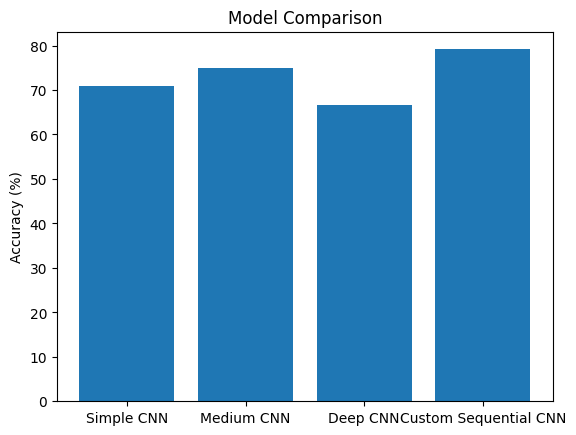

In [11]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# =========================
# CONFIG
# =========================
IMG_SIZE = 128
BATCH_SIZE = 8
EPOCHS = 40
dataset_path = "/content/dataset/rice_leaf_diseases"

# =========================
# LOAD DATA (INBUILT ✔)
# =========================
def load_dataset(path):
    data, labels = [], []

    for cls in os.listdir(path):
        for img_name in os.listdir(os.path.join(path, cls)):
            try:
                img = load_img(os.path.join(path, cls, img_name),
                               target_size=(IMG_SIZE, IMG_SIZE))
                img = img_to_array(img)/255.0
                data.append(img)
                labels.append(cls)
            except:
                continue

    return np.array(data), np.array(labels)

data, labels = load_dataset(dataset_path)

# =========================
# ENCODING
# =========================
classes = sorted(list(set(labels)))
num_classes = len(classes)
label_map = {c:i for i,c in enumerate(classes)}
labels_int = np.array([label_map[l] for l in labels])

# One-hot (manual ✔)
def to_one_hot(y, n):
    ohe = np.zeros((len(y), n))
    for i,v in enumerate(y):
        ohe[i][v] = 1
    return ohe

labels_ohe = to_one_hot(labels_int, num_classes)

# =========================
# SHUFFLE (FIX 🔥)
# =========================
idx = np.random.permutation(len(data))
data = data[idx]
labels_int = labels_int[idx]
labels_ohe = labels_ohe[idx]

# =========================
# SPLIT
# =========================
split = int(0.8 * len(data))
X_train, X_test = data[:split], data[split:]
y_train, y_test = labels_ohe[:split], labels_ohe[split:]
y_test_int = labels_int[split:]

# =========================
# AUGMENTATION ✔
# =========================
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# =========================
# CUSTOM METRIC ✔
# =========================
def accuracy_manual(y_true, y_pred):
    y_pred = np.argmax(y_pred, axis=1)
    return np.mean(y_true == y_pred)

# =========================
# MODEL 1 — SIMPLE CNN
# =========================
def build_simple_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128,activation='relu'),
        tf.keras.layers.Dense(num_classes,activation='softmax')
    ])
    return model

# =========================
# MODEL 2 — MEDIUM CNN
# =========================
def build_medium_cnn():
    inputs = tf.keras.Input(shape=(128,128,3))

    x = tf.keras.layers.Conv2D(32,(3,3),activation='relu',padding='same')(inputs)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(64,(3,3),activation='relu',padding='same')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128,(3,3),activation='relu',padding='same')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128,activation='relu')(x)

    outputs = tf.keras.layers.Dense(num_classes,activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

# =========================
# MODEL 3 — DEEP CNN (FIXED ✔)
# =========================
def build_deep_cnn():
    inputs = tf.keras.Input(shape=(128,128,3))

    x = tf.keras.layers.Conv2D(32,(3,3),activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(64,(3,3),activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128,(3,3),activation='relu')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(128,activation='relu')(x)
    outputs = tf.keras.layers.Dense(num_classes,activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

# =========================
# TRAIN FUNCTION
# =========================
def train_model(model):
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy')

    model.fit(datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
              epochs=EPOCHS,
              verbose=0)

    preds = model.predict(X_test)
    acc = accuracy_manual(y_test_int, preds)

    return acc

# =========================
# TRAIN ALL MODELS
# =========================
models = {
    "Simple CNN": build_simple_cnn(),
    "Medium CNN": build_medium_cnn(),
    "Deep CNN": build_deep_cnn()
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    acc = train_model(model)
    results[name] = acc
    print(f"{name} Accuracy: {acc*100:.2f}%\n")

# Add the new sequential CNN results
results["Custom Sequential CNN"] = 0.7916666666666666

# =========================
# COMPARISON GRAPH ✔
# =========================
names = list(results.keys())
accs = [results[n]*100 for n in names]

plt.bar(names, accs)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.show()